### Ноутбук расчетов контрфактических траекторий после и контрфактических реакций

значение функции потерь на исторических данных 0.801


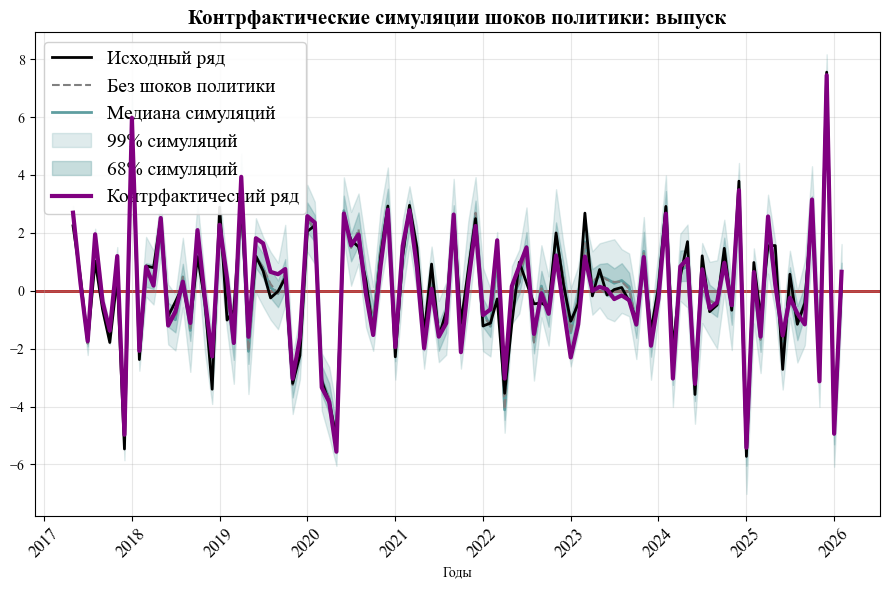

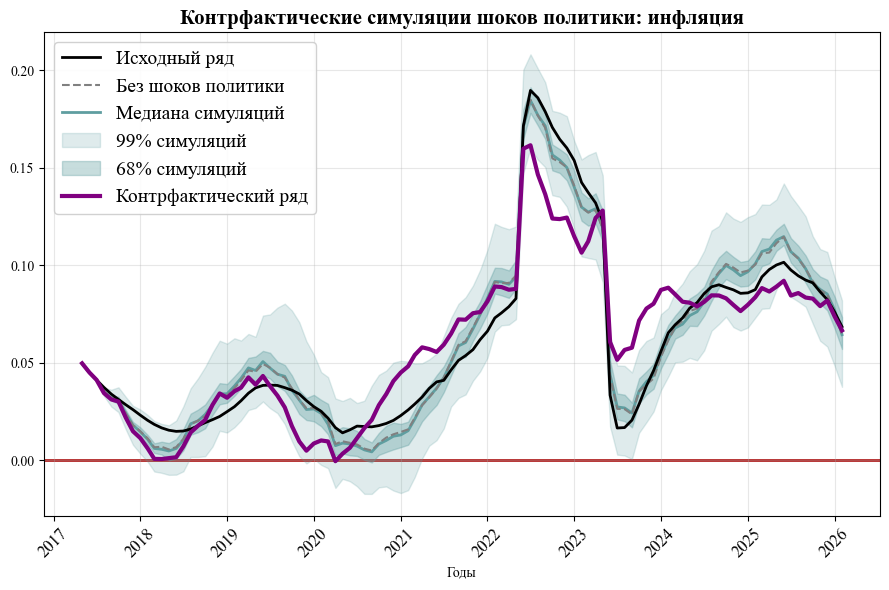

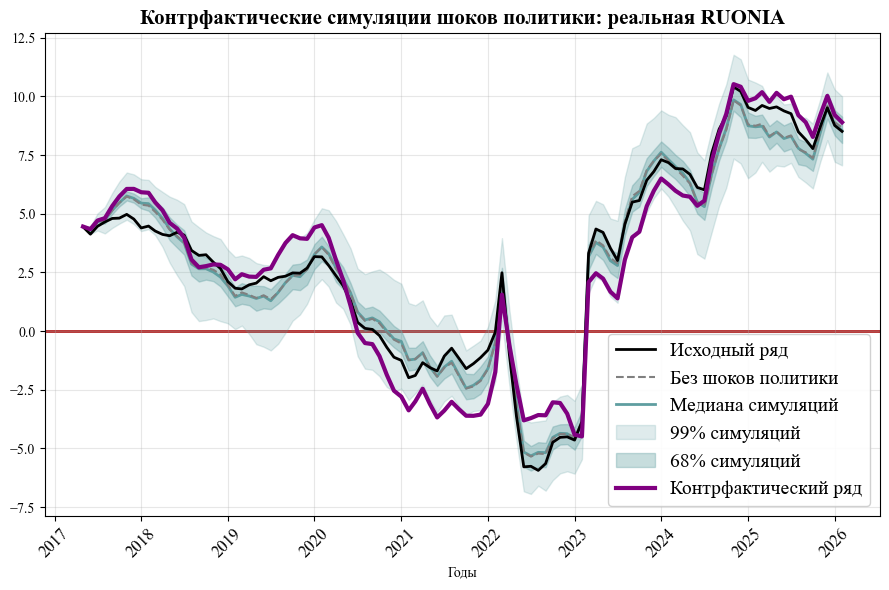

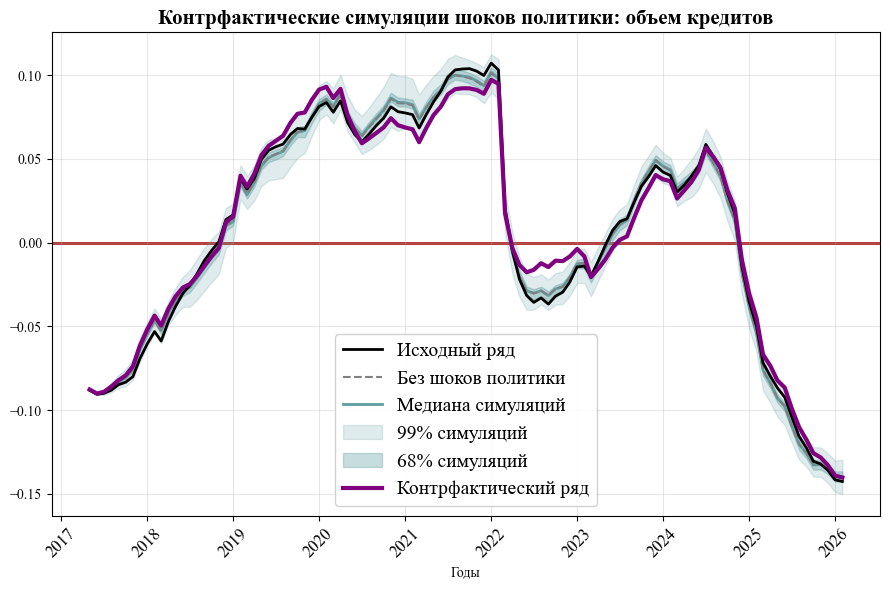

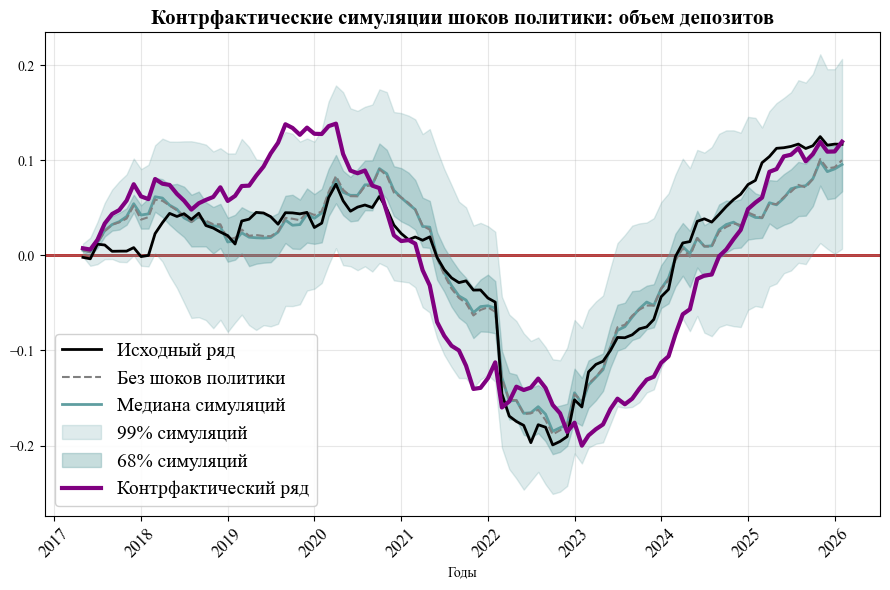

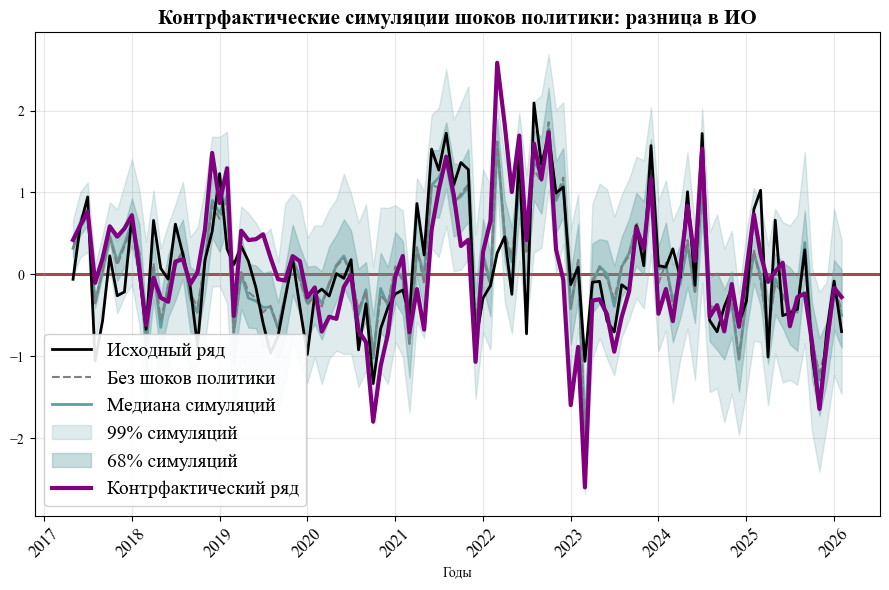

In [1]:
import numpy as np

import pickle
filename = 'data/monthly_data.pkl'
with open(filename, 'rb') as f:
    monthly_data = pickle.load(f)

from structuralvar import Clean, SVAR_KL

with open('data/main_hetemodel.pkl', 'rb') as f:
    model, var_spec, data, base_level, raw_data = pickle.load(f)
with open('data/cf_result.pkl', 'rb') as f:
    cf_result = pickle.load(f)

cf_sims = model.cf_policy_space(
    policy_shock_index=[2],
    ar_order=6,
    pacf_bounds=(-0.8, 0.8))
for key in list(model.y_dict.keys()):
    cf_sims[key]['cf_serie'] = cf_result.counterfactual_model._raw_data.loc[key].iloc[model.p:]

# значение функции потерь на исторических данных
pi_target = [var_spec.transform_to_clean(0.327, var_name='ru_cpi', t_index=t) for t in range(model.T)][model.p:]
def pi_lf(target_series, pi_target):
    return np.mean((target_series-pi_target)**2)

print(f"значение функции потерь на исторических данных {pi_lf(
    model._raw_data.loc['ru_cpi'].to_numpy()[model.p:],
    pi_target).round(3)}")
pi_e_ws = data.loc['pi_e_ws']
pi_e_ws = np.array([var_spec.transform_to_real(pi_e_ws.iloc[i - model.p],
                                    var_name='pi_e_ws', t_index=i) for i in range(model.p, model.T)])

start_of_infl = raw_data.iloc[:12+model.p, 0]/100 + 1

infl = cf_sims['ru_cpi']['original']
infl = np.array([var_spec.transform_to_real(infl[i - model.p], var_name='ru_cpi', t_index=i) for i in range(model.p, model.T)])/100 + 1
infl = np.concat([start_of_infl, infl])
ys_list = [infl[i:12+i] for i in range(infl.shape[0]-12)]
infl = np.array([ys.prod() for ys in ys_list])

cf_sims['ru_cpi']['original'] = infl[:model.nobs]-1
cf_sims['real_ruonia']['original'] = np.array([var_spec.transform_to_real(cf_sims['real_ruonia']['original'][i - model.p],
                                               var_name='real_ruonia', t_index=i) for i in range(model.p, model.T)])


infl = cf_sims['ru_cpi']['clean']
infl = np.array([var_spec.transform_to_real(infl[i - model.p], var_name='ru_cpi', t_index=i) for i in range(model.p, model.T)])/100 + 1
infl = np.concat([start_of_infl, infl])
ys_list = [infl[i:12+i] for i in range(infl.shape[0]-12)]
infl = np.array([ys.prod() for ys in ys_list])

cf_sims['ru_cpi']['clean'] = infl[:model.nobs]-1
cf_sims['real_ruonia']['clean'] = np.array([var_spec.transform_to_real(cf_sims['real_ruonia']['clean'][i - model.p],
                                               var_name='real_ruonia', t_index=i) for i in range(model.p, model.T)])


infl = cf_sims['ru_cpi']['cf_serie'].to_numpy()
infl = np.array([var_spec.transform_to_real(infl[i - model.p], var_name='ru_cpi', t_index=i) for i in range(model.p, model.T)])/100 + 1
infl = np.concat([start_of_infl, infl])
ys_list = [infl[i:12+i] for i in range(infl.shape[0]-12)]
infl = np.array([ys.prod() for ys in ys_list])

cf_sims['ru_cpi']['cf_serie'] = infl[:model.nobs]-1
cf_sims['real_ruonia']['cf_serie'] = np.array([var_spec.transform_to_real(cf_sims['real_ruonia']['cf_serie'].to_numpy()[i - model.p],
                                               var_name='real_ruonia', t_index=i) for i in range(model.p, model.T)])


for idx, (infl, ruonia, hete) in enumerate(zip(
    cf_sims['ru_cpi']['sims'],
    cf_sims['real_ruonia']['sims'],
    cf_sims['pi_e_hete']['sims'])
    ):
    
    infl = np.array([var_spec.transform_to_real(infl[i - model.p], var_name='ru_cpi', t_index=i) for i in range(model.p, model.T)])/100 + 1
    infl = np.concat([start_of_infl, infl])
    ys_list = [infl[i:12+i] for i in range(infl.shape[0]-12)]
    infl = np.array([ys.prod() for ys in ys_list])

    cf_sims['ru_cpi']['sims'][idx] = infl[:model.nobs]-1
    cf_sims['real_ruonia']['sims'][idx] = np.array([var_spec.transform_to_real(ruonia[i - model.p], 
                                                    var_name='real_ruonia', t_index=i) for i in range(model.p, model.T)])


model.plot_policy_space(
    cf_results=cf_sims,
    ci_levels = (68, 99),
    figsize = (9,6))

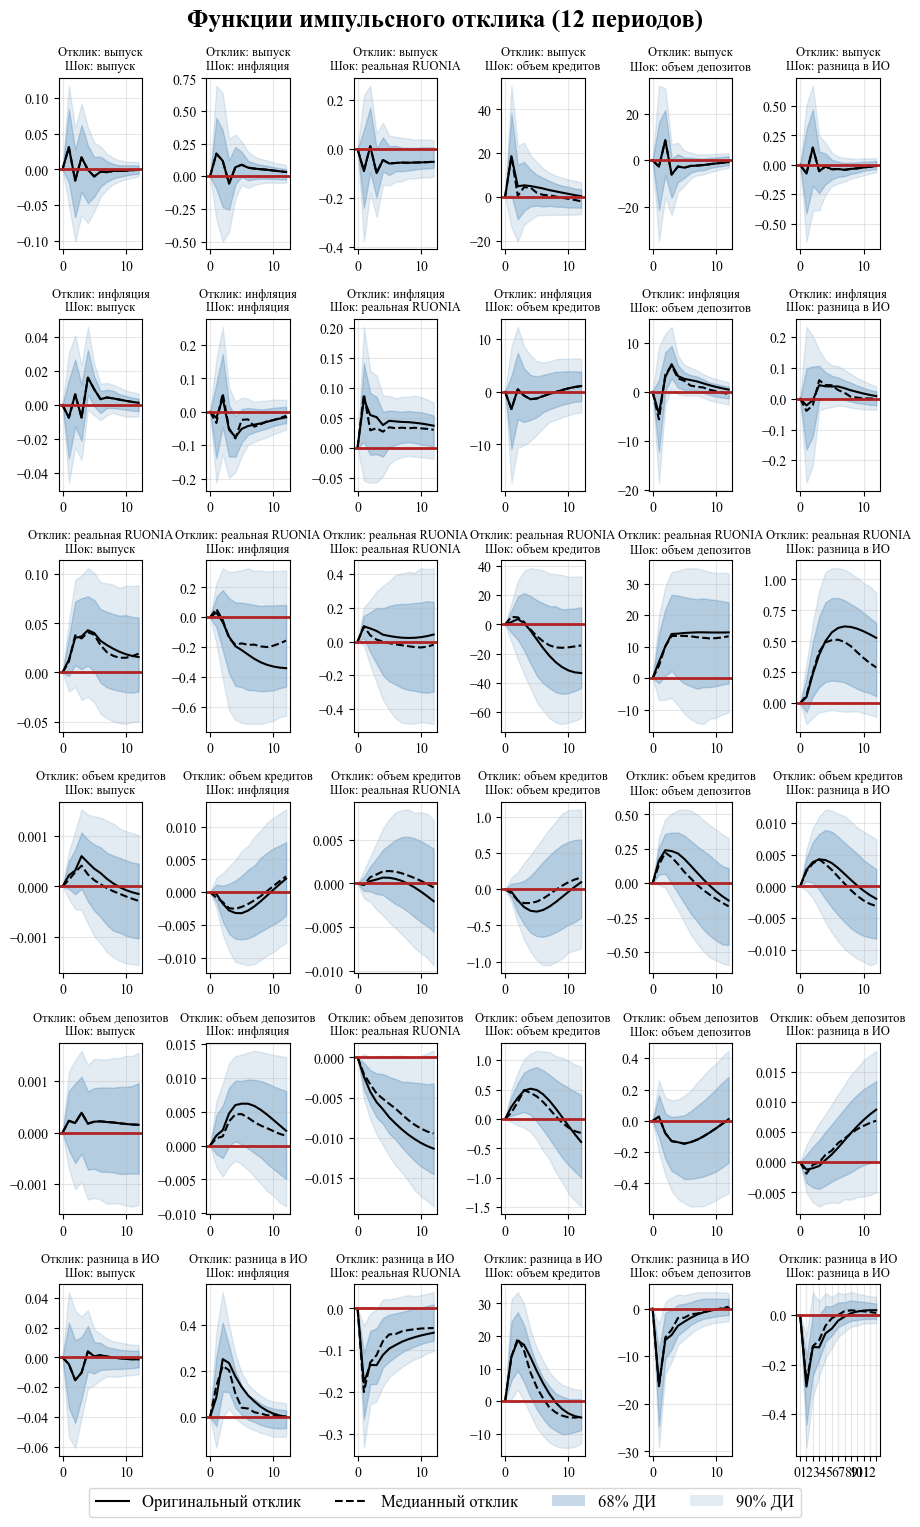

In [2]:
cf_model = cf_result.counterfactual_model.fit_ols()
cf_model.set_base_levels(base_level)
cf_irf0 = cf_model.irf(horizon = cf_model.T-cf_model.p, B0inv=np.eye(cf_model.K))
required = 1000
cf_model.Q = np.eye(cf_model.K)
cf_irf_draws = cf_model.irf_bootstrap(
    horizon = cf_model.T-cf_model.p,
    n_boot=required-1,
    seed=1,
    scheme="innovations"
)

cf_irf_sims = [cf_irf0] + [cf_irf_draws[b] for b in range(cf_irf_draws.shape[0])]
inn_irf_draws = model.irf_bootstrap(
    horizon = model.nobs,
    n_boot=required-1,
    seed=1,
    scheme="innovations"
)
inn_irf0 = model.irf(horizon = model.nobs, B0inv=np.eye(model.K))

inn_irf_sims = [inn_irf0] + [inn_irf_draws[b] for b in range(inn_irf_draws.shape[0])]

diff_irf_sims = []
for i, (inn, cf) in enumerate(zip(inn_irf_sims, cf_irf_sims)):
    diff_irf_sims += [inn-cf]
model.plot_irfs_grid(irf_sims=diff_irf_sims,
                     horizon_plot=12,
                     percent=False,
                     main_color='steelblue',
                     innovations = True)

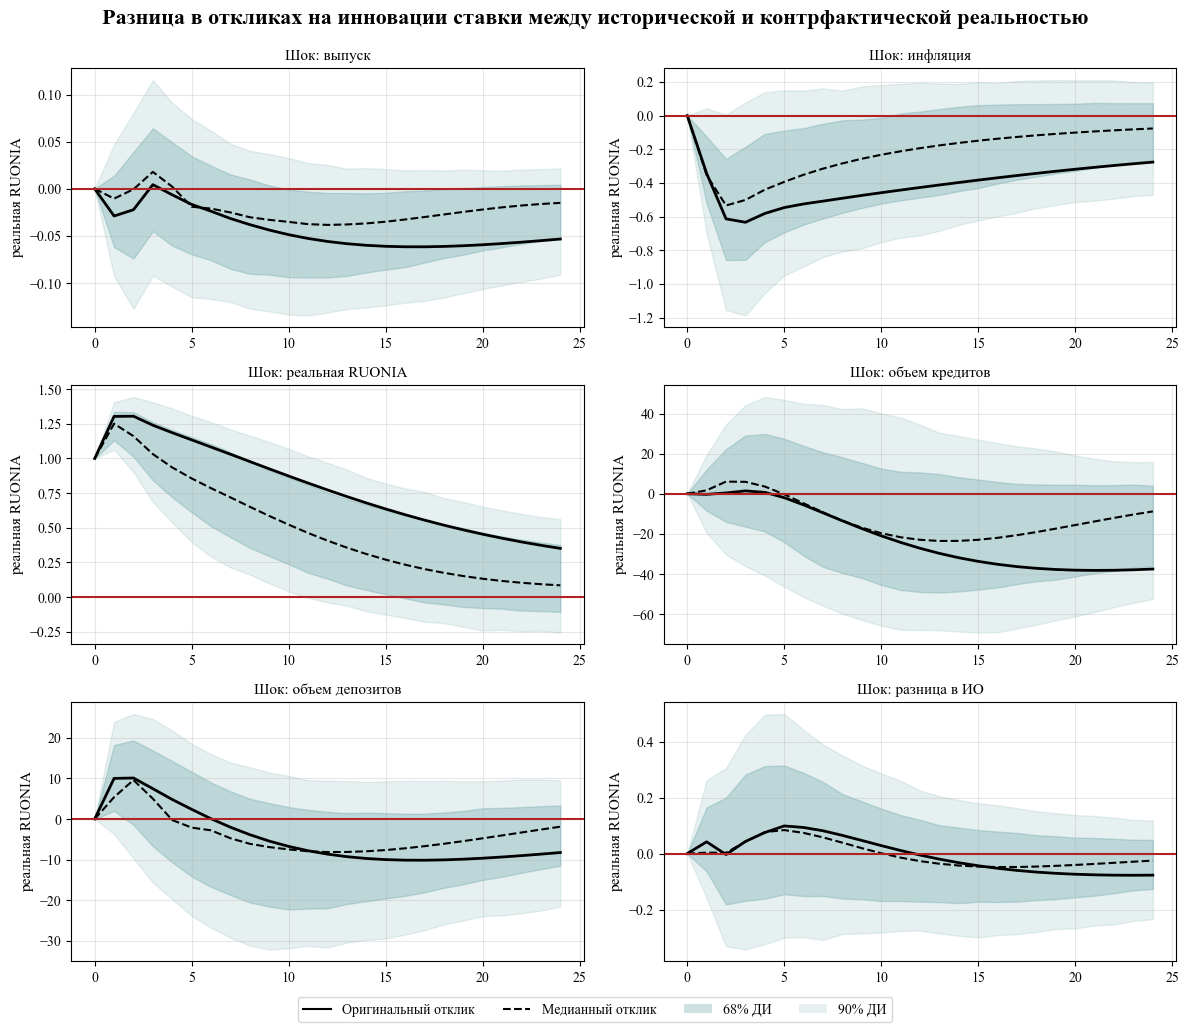

In [3]:
model.plot_single_var_grid(inn_irf_sims,
                           response_var = 2,
                           horizon = 24,
                           innovations = True,
                           title = 'Разница в откликах на инновации ставки между исторической и контрфактической реальностью')

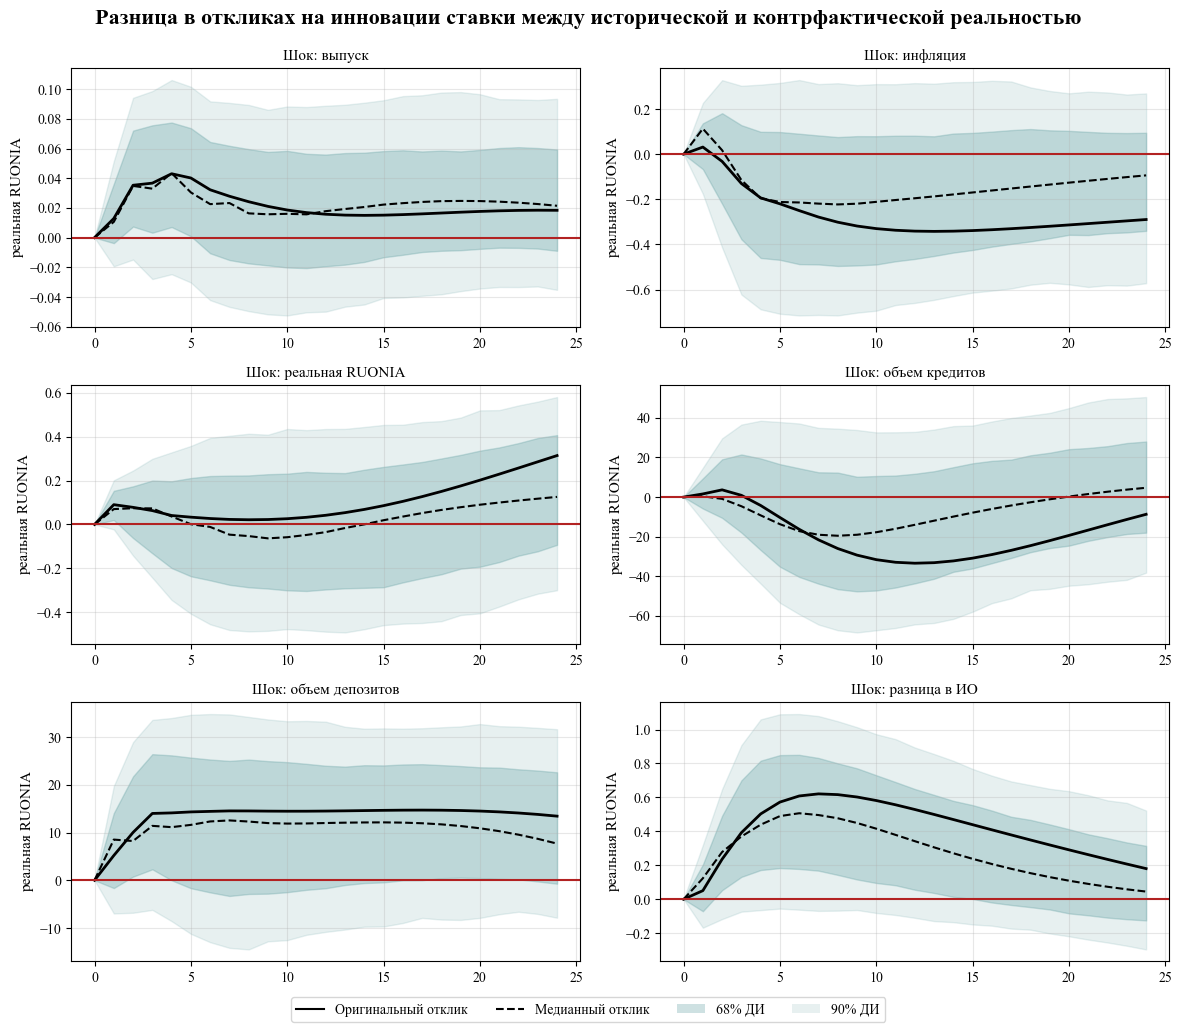

In [4]:
model.plot_single_var_grid(diff_irf_sims,
                           response_var = 2,
                           horizon = 24,
                           innovations = True,
                           title = 'Разница в откликах на инновации ставки между исторической и контрфактической реальностью')

In [5]:
(np.array([diff_irf_sims[sim][:24, 2, 5].sum() for sim in range(required)])>0).sum()/required

np.float64(0.916)

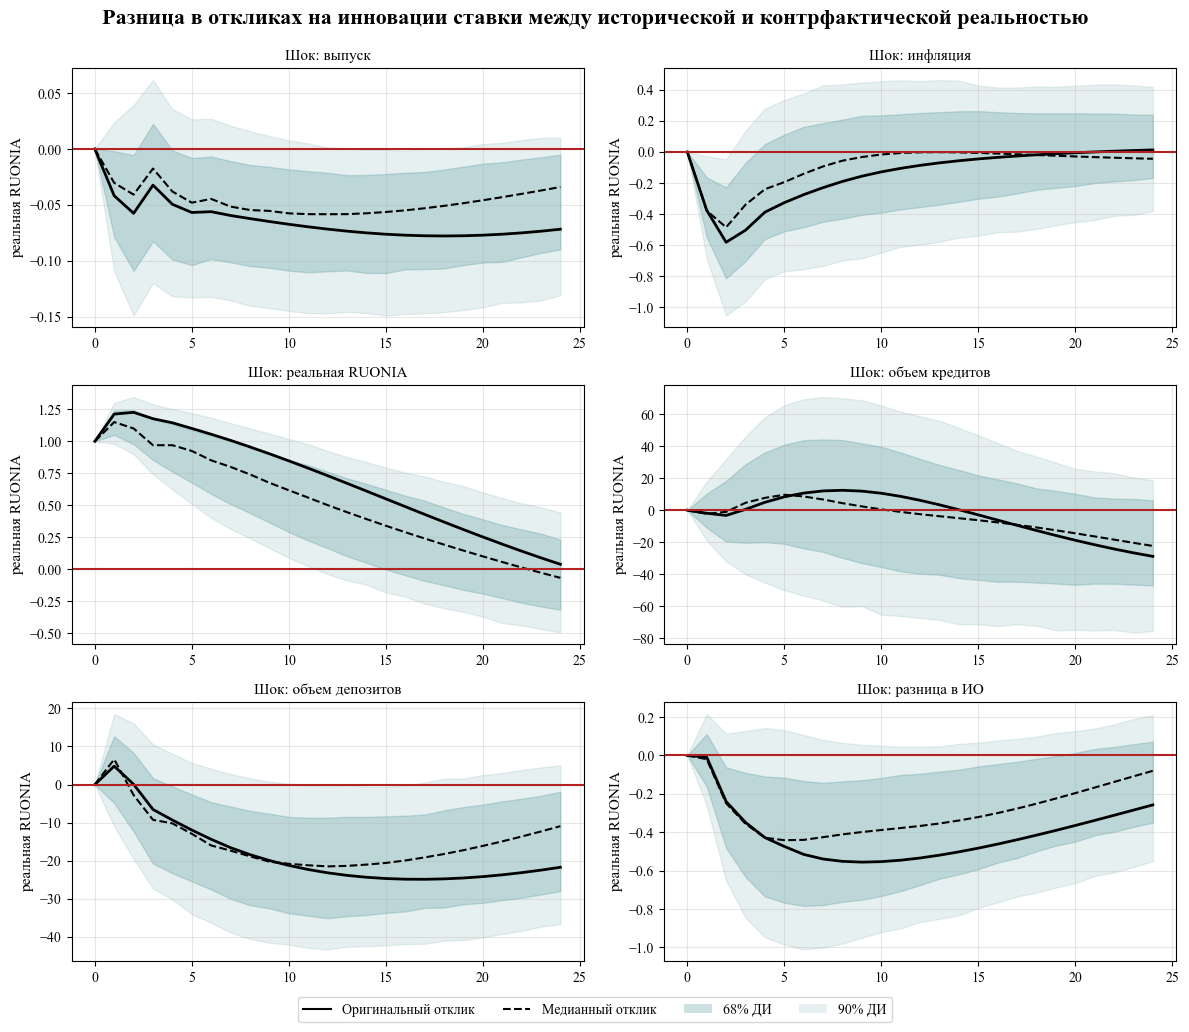

In [6]:
model.plot_single_var_grid(cf_irf_sims,
                           response_var = 2,
                           horizon = 24,
                           innovations = True,
                           title = 'Разница в откликах на инновации ставки между исторической и контрфактической реальностью')

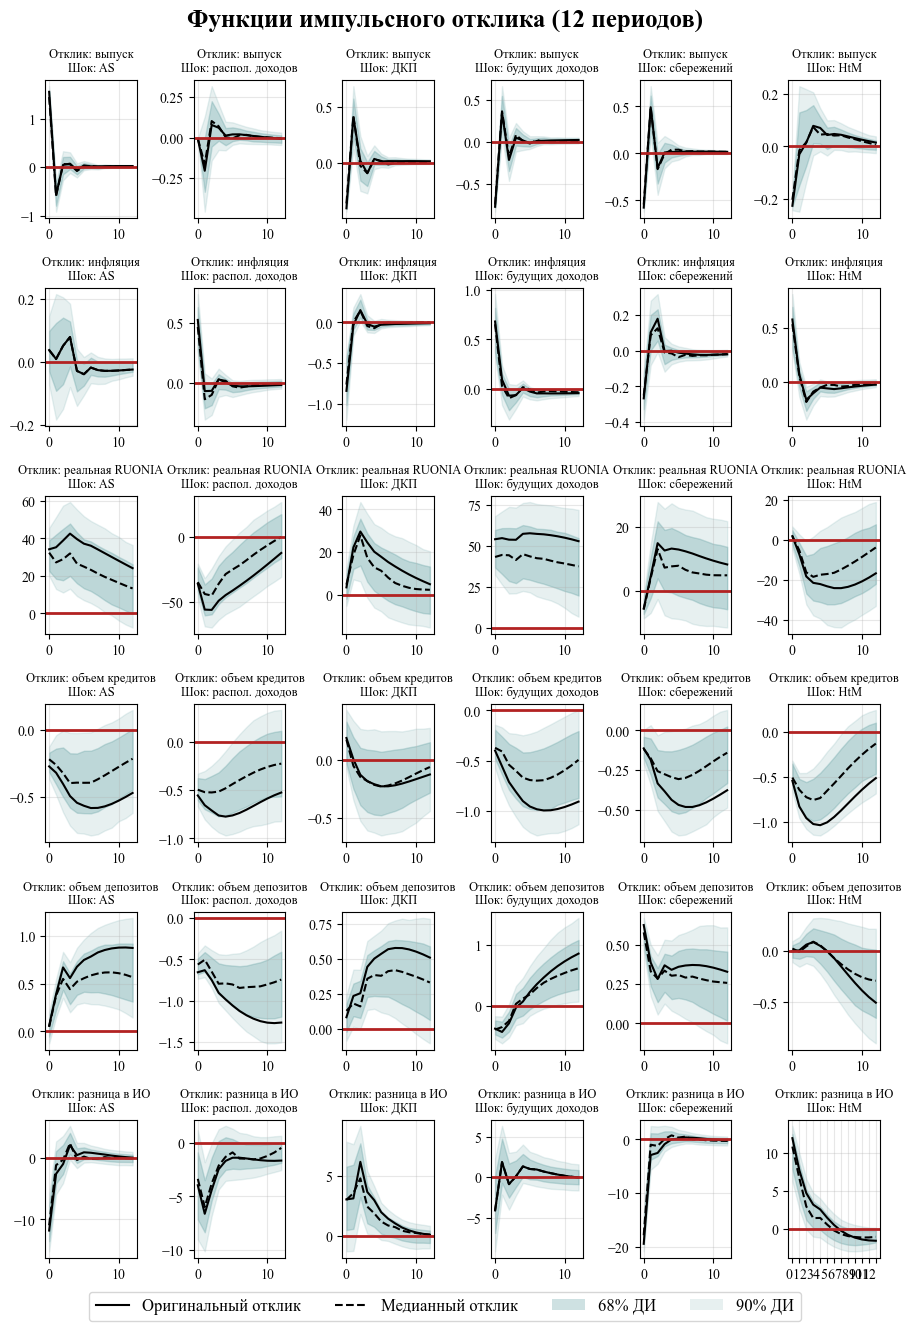

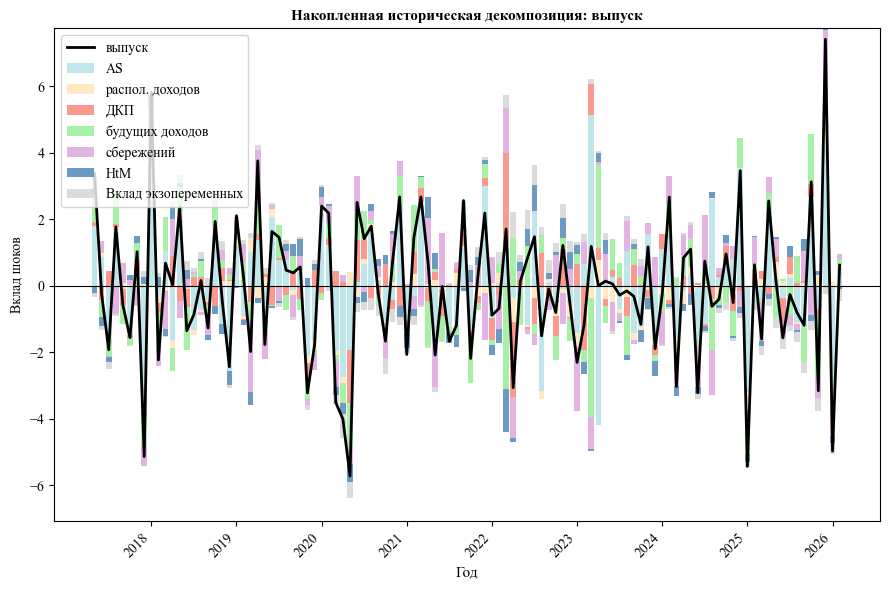

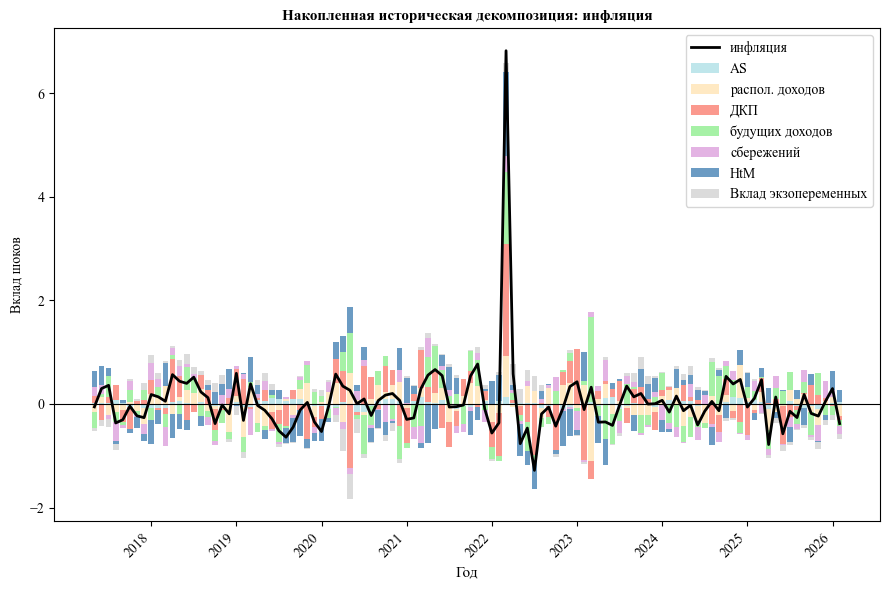

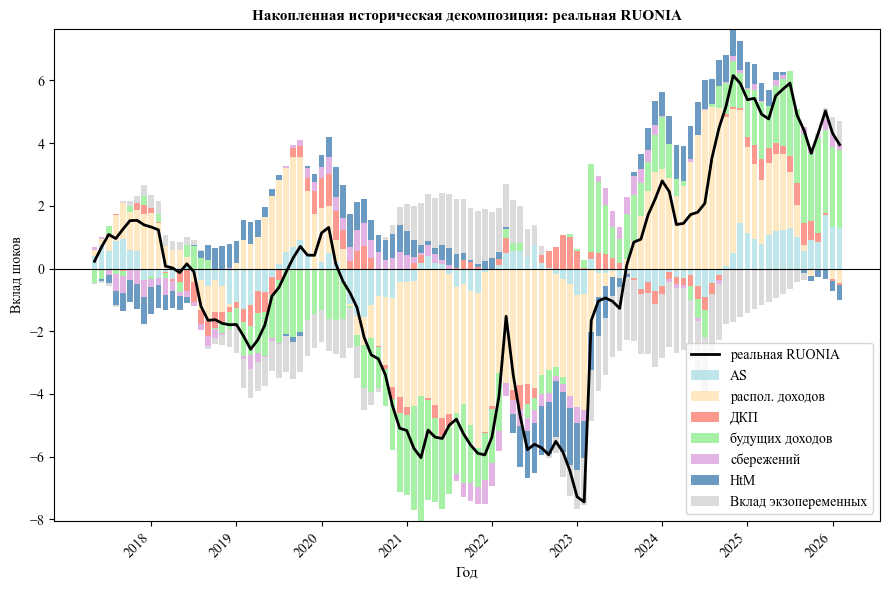

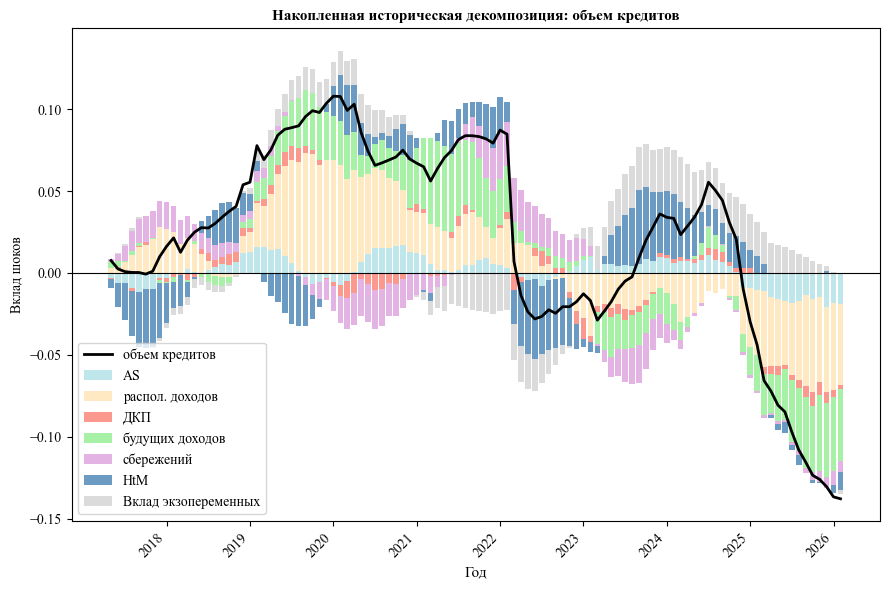

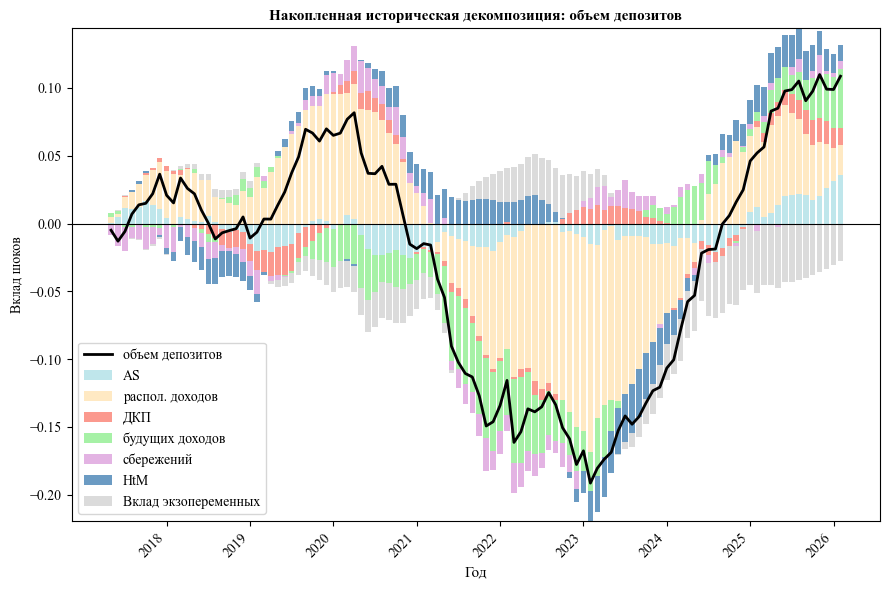

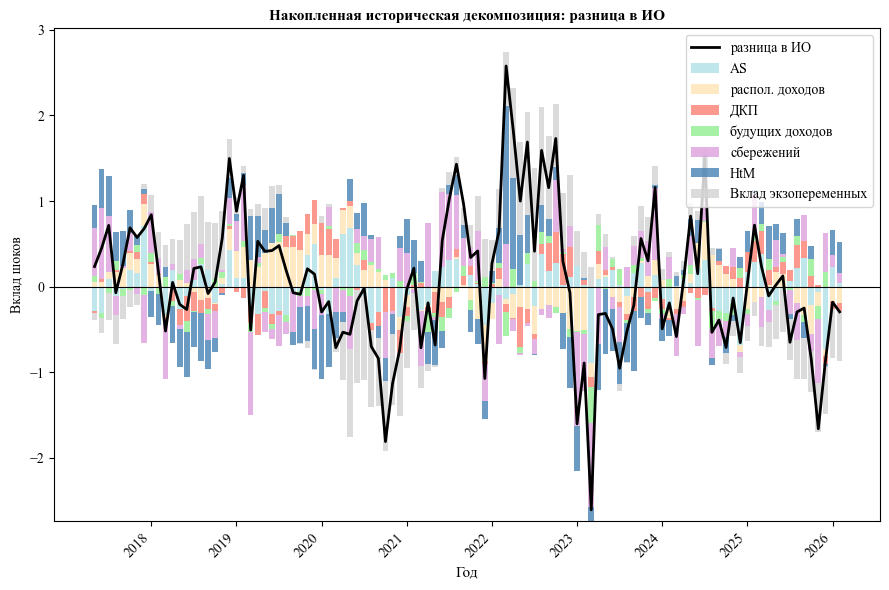

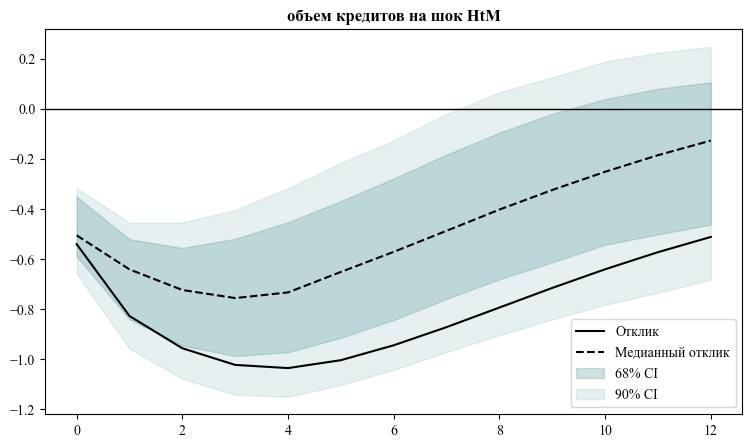

In [7]:
short_run_anchor = [
    (0, 0, 1, 0, 100),
    (0, 4, 5, 0, 10),
    (0, 4, 5, 1, 10),

]
long_run_anchor = [
    (0, 2, 2, 1),
    (0, 4, 5, 1),
    (0, 0, 1, 1),
    (0, 0, 1, 1),
]
short_run_signs = [
    (0, 1, 2, False, 0, 100),
    (0, 1, 2, False, 1, 100),
    (0, 1, 2, False, 2, 50),
    (0, 1, 3, True, 0, 4),
    (0, 0, 2, False, 0, 10),
    (0, 5, 1, False, 0, 1),
    (0, 5, 3, False, 0, 1),
    (0, 2, 4, False, 0, 1),

    (0, 3, 1, False, 0, 1),
    (0, 1, 1, True, 0, 1),
    (0, 0, 1, True, 1, 1),



    (0, 0, 0, True, 0, 1),
    (0, 1, 1, True, 0, 1),
    (0, 2, 2, True, 0, 10),
    (0, 3, 3, True, 0, 1),
    (0, 4, 4, True, 0, 1),
    (0, 5, 5, True, 0, 1),
]
long_run_signs = [
    (0, 3, 5, False, 1),
    (0, 2, 1, True, 1),
    (0, 1, 2, False, 10),
    (0, 0, 0, True, 1),
    (0, 0, 1, True, 1),
    (0, 3, 2, False, 1),
    (0, 4, 4, True, 1),
    (0, 5, 5, True, 1)
]
lag = 2

cf_rr = cf_model.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 120
cf_irf0 = cf_model.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

cf_irf_draws = cf_model.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

cf_irf_sims = [cf_irf0] + [cf_irf_draws[b] for b in range(cf_irf_draws.shape[0])]
cf_model.plot_irfs_grid(irf_sims=cf_irf_sims,
                     horizon_plot=12,
                     main_color='cadetblue', 
                     figsize = (9, 13))

cf_model.print_upsilon()
hd, contrib_df = cf_model.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = False,
                                    const_clean = True)
cf_model.plot_single_irf(irf_sims = cf_irf_sims,
                      horizon=12,
                      variable='log_credits_hh',
                      shock = 'HtM',
                      ci_color = 'cadetblue',
                      plot_simulations = False)



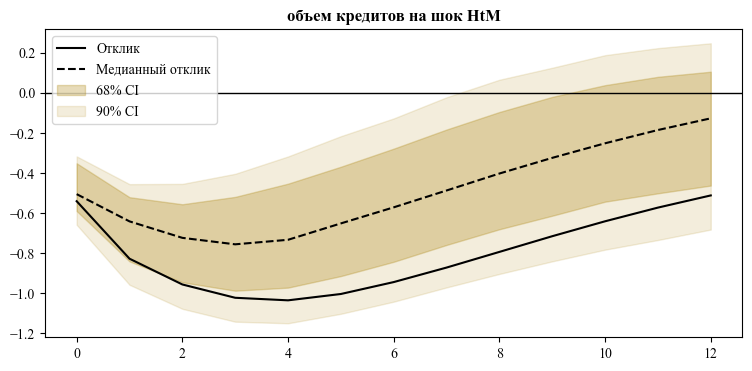

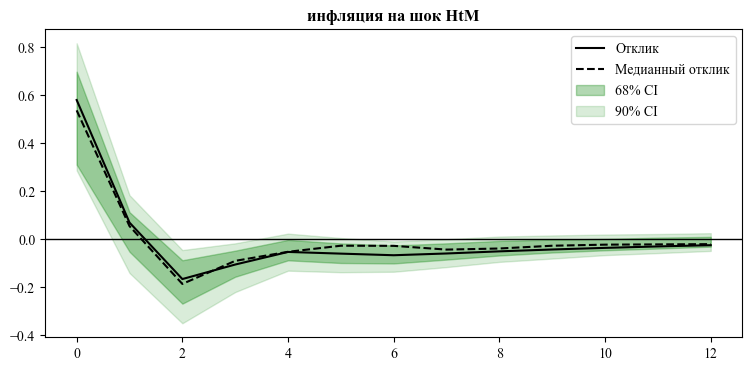

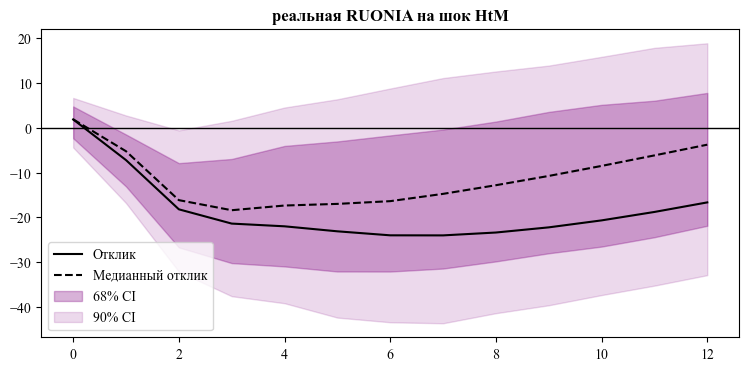

In [8]:
model.plot_single_irf(irf_sims = cf_irf_sims,
                      horizon=12,
                      variable='log_credits_hh',
                      shock = 'HtM',
                      ci_color = "#B08A19",
                      plot_simulations = False,
                      figsize = (9,4))
model.plot_single_irf(irf_sims = cf_irf_sims,
                      horizon=12,
                      variable='ru_cpi',
                      shock = 'HtM',
                      ci_color = 'green',
                      plot_simulations = False,
                      figsize = (9,4))
model.plot_single_irf(irf_sims = cf_irf_sims,
                      horizon=12,
                      variable='real_ruonia',
                      shock = 'HtM',
                      ci_color = 'purple',
                      plot_simulations = False,
                      figsize = (9,4))


In [11]:
contrib_df

,выпуск,инфляция,реальная RUONIA,объем кредитов,объем депозитов,разница в ИО
AS,34.3,3.7,8.9,7.3,7.9,12.3
распол. доходов,5.2,15.3,34.1,27.1,40.8,11.4
ДКП,10.8,22.4,5.4,3.9,5.1,7.5
будущих доходов,17.8,19.5,19.0,17.7,14.0,4.8
сбережений,16.9,9.7,4.4,10.5,6.6,19.5
HtM,6.3,18.4,9.6,17.8,9.6,17.5
Ошибка модели,5.2,6.3,15.7,12.9,13.3,21.3
Вклад экзопеременных,3.4,4.8,2.8,2.8,2.6,5.7
